## Puprose of Notebook ## 

Matching DES SNIa to host galaxies listed as part of the DR1 DESI data release. 

## Content of DESI Galaxy Metadata Files ##



Please note that in this notebook there are two .fits files:

- `desi_galaxy_metadata_dark.fits`
-  `desi_galaxy_metadata.fits`

These files were filtered out from the main raw data files found at: 

https://data.desi.lbl.gov/public/dr1/

What Each Collumn of raw .fits files means: https://fastspecfit.readthedocs.io/en/stable/fastspec.html


The filtering consisted of getting out only galaxy related information from agregate data 
that was part of both the dark and bright iron fits survey.

The original desi data contained Qasuars Stars and Galaxies. The filtering work done here 
involved only looking at the Galaxy data and taking out the following parameters:

['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']

For the work on how this was done please refer to:

`DES5YR_DESI_explore.ipynb`

## More detials on how data was sourced: ##

The reference for the following description is the following paper: https://arxiv.org/abs/2503.14745

Within each survey, objects are observed in one of three possible programs, depending on the acceptable lunar phase and on-sky observing conditions:

- **bright** — Observed during bright time (e.g., near full Moon)
- **dark** — Observed during dark time (e.g., new Moon)
- **backup** — Observed when conditions are not ideal for primary programs

I chose to focus only on the bright and dark survey. This is where the two data files end up coming from. Backup data set was ignored b/c it contained secondary and tertiary targets.

### Spectroscopic Production in DESI DR1 - IRON

Spectroscopic production: full, systematic data processing pipeline run on a defined set of raw DESI spectroscopic exposures. Each production results in calibrated spectra, redshifts, and other derived quantities that are released for public use and scientific analysis.

The primary spectroscopic production for DR1 is called **Iron**, named after the Iron Mountain in Utah. This production includes data from the first 13 months of the DESI main survey, as well as a uniform reprocessing of the Science Validation (SV) data that was previously part of the Early Data Release (EDR). 

In addition to Iron, DR1 also includes a supplemental production called **Guadalupe** (named after the Guadalupe Mountains in Texas), which contains data from just the first two months of the main survey. Although Guadalupe was used in early DESI analyses, it was processed using the same calibration and software as the older Fuji production used in the EDR. As such, Iron should be preferred over Guadalupe for any current or future work, due to its broader coverage and superior data processing quality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table, hstack, vstack  # <-- added vstack here
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

# ZTF Host Galaxy Coordiantes #

The ZTF DR2 releases its host galaxy coordiantes in a separate .csv to the one that lits light curve parameters. So the following code is just there to stich together the `ZTF_snia_data.csv` and `globalhost_data.csv` and `localhost_data.csv`



In [2]:
snia_path = "data/ZTF_snia_data.csv"
host_path = "data/globalhost_data.csv"
local_path = "data/localhost_data.csv"

df_snia = pd.read_csv(snia_path)
df_host = pd.read_csv(host_path)
df_local = pd.read_csv(local_path)

# Blanket rename: suffix all columns except the merge key
for c in df_host.columns:
    if c != "ztfname":
        df_host = df_host.rename(columns={c: c + "_global"})
        
for c in df_local.columns:
    if c != "ztfname":
        df_local = df_local.rename(columns={c: c + "_local"})

# Merge on ztfname
# Left Merge: keep every row from the left table (df_snia), 
# and if a matching ztfname exists in the right table (df_host), 
# attach those columns. If there's no match, the right-side columns get filled with NaN.
df_merged = pd.merge(df_snia, df_host, on="ztfname", how="left")
df_merged = pd.merge(df_merged, df_local, on="ztfname", how="left")


# Rename the prefix of the ZTF side of the data. Will come in handy when it comes to
# matching our data with DESI Galaxy catalogue later.
# 
for c in df_merged.columns:
    if c != "ztfname":
        df_merged = df_merged.rename(columns={c: "ZTF_" + c})
        
# df_merged.to_csv("data/ZTF_snia_dr2_info_complete.csv", index=False)

# Checking to make sure that everything got printed as it should have. 
print(df_merged.columns.tolist())

['ZTF_Unnamed: 0', 'ztfname', 'ZTF_redshift', 'ZTF_redshift_err', 'ZTF_source', 'ZTF_t0', 'ZTF_x0', 'ZTF_x1', 'ZTF_c', 'ZTF_t0_err', 'ZTF_x0_err', 'ZTF_x1_err', 'ZTF_c_err', 'ZTF_cov_t0_x0', 'ZTF_cov_t0_x1', 'ZTF_cov_t0_c', 'ZTF_cov_x0_x1', 'ZTF_cov_x0_c', 'ZTF_cov_x1_c', 'ZTF_mwebv', 'ZTF_mwr_v', 'ZTF_mwebv_err', 'ZTF_fitprob', 'ZTF_ra', 'ZTF_dec', 'ZTF_sn_type', 'ZTF_sub_type', 'ZTF_lccoverage_flag', 'ZTF_fitquality_flag', 'ZTF_iau_name', 'ZTF_frac_fitted', 'ZTF_ra_host_global', 'ZTF_dec_host_global', 'ZTF_mass_global', 'ZTF_mass_err_global', 'ZTF_restframe_gz_global', 'ZTF_restframe_gz_err_global', 'ZTF_d_dlr_global', 'ZTF_mass_local', 'ZTF_mass_err_local', 'ZTF_restframe_gz_local', 'ZTF_restframe_gz_err_local']


# Check for Null Entries #

Looks like light curve parameters and some mass features are null we will have to drop them. 

In [3]:
print(df_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3628 entries, 0 to 3627
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ZTF_Unnamed: 0               3628 non-null   int64  
 1   ztfname                      3628 non-null   object 
 2   ZTF_redshift                 3628 non-null   float64
 3   ZTF_redshift_err             3628 non-null   float64
 4   ZTF_source                   3628 non-null   object 
 5   ZTF_t0                       3592 non-null   float64
 6   ZTF_x0                       3576 non-null   float64
 7   ZTF_x1                       3576 non-null   float64
 8   ZTF_c                        3576 non-null   float64
 9   ZTF_t0_err                   3576 non-null   float64
 10  ZTF_x0_err                   3576 non-null   float64
 11  ZTF_x1_err                   3576 non-null   float64
 12  ZTF_c_err                    3576 non-null   float64
 13  ZTF_cov_t0_x0     

### Dropping Null Entreis ###
Dropping entries that would make our analysis difficult/useless if they are missing.

Looking for things with missing host galaxy coordiantes - making association useless.

Missing light curve information - which would make computing the distance modulus impossible.

Looks like were were able to get everything that included light curve parameters and things like that done and accounted for. Some entreis that are related to host galaxy properties are still null, but we will be sourcing them from the DESI catalogue anyway and thus will not be dropping those at all. 



In [4]:
# Drops the entries where ra_host OR the dec_host are missing:
df_merged_wt_hosts = df_merged.dropna(subset=["ZTF_ra_host_global", "ZTF_dec_host_global"]).copy()

print("Hostmass na Drop")
print(f"Before drop: {len(df_merged)} rows")
print(f"After drop:  {len(df_merged_wt_hosts)} rows")
print(f"Dropped:     {len(df_merged) - len(df_merged_wt_hosts)} rows (missing host coordinates)")
print("\n")


# Drops the entries where any of the light curve parameters are nan:
df_merged_wt_hosts_and_lc = df_merged_wt_hosts.dropna(subset=["ZTF_t0", "ZTF_x0", "ZTF_x1", "ZTF_c",
    "ZTF_t0_err", "ZTF_x0_err", "ZTF_x1_err", "ZTF_c_err",
    "ZTF_cov_t0_x0", "ZTF_cov_t0_x1", "ZTF_cov_t0_c",
    "ZTF_cov_x0_x1", "ZTF_cov_x0_c", "ZTF_cov_x1_c"]).copy()


print("Light Curve na Drop")
print(f"Before drops: {len(df_merged_wt_hosts)} rows")
print(f"After drops:  {len(df_merged_wt_hosts_and_lc)} rows")
print(f"Dropped:      {len(df_merged_wt_hosts) - len(df_merged_wt_hosts_and_lc)} rows")
print("\n")

print(df_merged_wt_hosts_and_lc.info())

Hostmass na Drop
Before drop: 3628 rows
After drop:  3545 rows
Dropped:     83 rows (missing host coordinates)


Light Curve na Drop
Before drops: 3545 rows
After drops:  3494 rows
Dropped:      51 rows


<class 'pandas.core.frame.DataFrame'>
Index: 3494 entries, 0 to 3627
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ZTF_Unnamed: 0               3494 non-null   int64  
 1   ztfname                      3494 non-null   object 
 2   ZTF_redshift                 3494 non-null   float64
 3   ZTF_redshift_err             3494 non-null   float64
 4   ZTF_source                   3494 non-null   object 
 5   ZTF_t0                       3494 non-null   float64
 6   ZTF_x0                       3494 non-null   float64
 7   ZTF_x1                       3494 non-null   float64
 8   ZTF_c                        3494 non-null   float64
 9   ZTF_t0_err                   3494 non-null   float

## Matching Step ##

Using `astropy.coordinates.SkyCoord.match_to_catalog_sky`, we find the nearest DESI source to each SN host and keep only matches with angular separation < **1 arcsec** (a conservative radius to limit chance associations). 

For the surviving pairs we 
(i) select the matching rows from both tables

(ii) record the on-sky separation in arcseconds (`ANGSEP_ARCSEC`)

(iii) horizontally stack the SN and DESI columns so that each row represents one SN–host match. 

In [5]:
with fits.open("../../myc21_first_paper_LARGE_DATA/desi_bright_galaxy_metadata_mosthost.fits") as hdul:
    print("\n")
    hdul.info()
    print("\n")
    print("Collumn Names: " + str(hdul[1].columns.names))
    print("\n")
    print(f"Row count: {len(hdul[1].data)}")



Filename: ../../myc21_first_paper_LARGE_DATA/desi_bright_galaxy_metadata_mosthost.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     28   6346725R x 10C   [K, K, 6A, D, D, K, D, K, 4A, 6A]   


Collumn Names: ['TARGETID', 'LS_ID', 'SPECTYPE', 'RA', 'DEC', 'DESI_TARGET', 'Z', 'ZWARN', 'SURVEY', 'PROGRAM']


Row count: 6346725


In [6]:
with fits.open("../../myc21_first_paper_LARGE_DATA/desi_dark_galaxy_metadata_mosthost.fits") as hdul:
    print("\n")
    hdul.info()
    print("\n")
    print("Collumn Names: " + str(hdul[1].columns.names))
    print("\n")
    print(f"Row count: {len(hdul[1].data)}")



Filename: ../../myc21_first_paper_LARGE_DATA/desi_dark_galaxy_metadata_mosthost.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     28   8490171R x 10C   [K, K, 6A, D, D, K, D, K, 4A, 4A]   


Collumn Names: ['TARGETID', 'LS_ID', 'SPECTYPE', 'RA', 'DEC', 'DESI_TARGET', 'Z', 'ZWARN', 'SURVEY', 'PROGRAM']


Row count: 8490171


In [7]:
df_merged_wt_hosts_and_lc

# Create SkyCoord object for ZTF DR2 hostgalaxy_locations
sn_coords = SkyCoord(
    ra=df_merged_wt_hosts_and_lc["ZTF_ra_host_global"].values * u.deg,
    dec=df_merged_wt_hosts_and_lc["ZTF_dec_host_global"].values * u.deg
)

# === Step 2: Load DESI Galaxy Metadata (Dark + Bright) === #
# Note there is a "most_host" entry in there and that is an artifact of the 
# fact that this came from some mosthost matches. Please ignore :) No 
# most host data exists there. 

fits_paths = [
    "../../myc21_first_paper_LARGE_DATA/desi_bright_galaxy_metadata_mosthost.fits",
    "../../myc21_first_paper_LARGE_DATA/desi_dark_galaxy_metadata_mosthost.fits"
]

# Simply combines the tables in memory so that we can work with one 
# combined data table.

desi_tables = []
for path in fits_paths:
    table = Table.read(path, hdu=1)
    desi_tables.append(table)

# vertically stacks the two fits files tables. Note they are identical
# and this is why the vstack operation works.
# exact option guarantees that we are not accidentally combining somehow
# mismatched tables.
# NOTE: desi_data is an ASTROPY table.
desi_data = vstack(desi_tables, join_type='exact')

# Create SkyCoord object for DESI galaxies 
desi_coords = SkyCoord(
    ra=desi_data["RA"] * u.deg,
    dec=desi_data["DEC"] * u.deg
)

# === Step 3: Match SN hosts to DESI galaxies ===
## for the coordiantes in sn_coords, find the closest object in `desi coords`
## idx[i] which row in the desi_coords is closest to the ZTF DR2 hostgal location in 
## sn coords.
## sep2D[i] is how far part these objects are on the sky. 
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Define a mask that Keep matches within 1 arcsecond
## match_mask is a boolena array that meets condition.
max_sep = 1 * u.arcsec
match_mask = sep2d < max_sep

# === Step 4: Extract matched rows ===
## This takes the DataFrame of valid SNIa that have host info (des_sn_valid) and filters
## it down to only the rows where match_mask is True.
## Table.from_pandas converts the pandas data frame to an astropy TABLE in order to
## take advantage of the Table.hstack feature.

## For matched_desi. First applies the same match_mask filtering to the idx array.
## Now you have only the DESI row indices for SNe that passed the 1 arcsecond cutoff.

## NOTE: desi_data is already in astropy Table format from above.
# has to "go through" idx to get to the right desi data. Like a bouncer at a club.

matched_sn = Table.from_pandas(df_merged_wt_hosts_and_lc[match_mask])
matched_desi = desi_data[idx[match_mask]] 

# Add angular separation (arcsec) collumn
matched_sn["ANGSEP_ARCSEC"] = sep2d[match_mask].arcsec

# Join matched tables
## This works mostly b/c idx was used ot make the two Tables lined up perfectly.
## So we can just horizontally stack them next to each other.
matched = hstack([matched_sn, matched_desi])


print(f"Matched {len(matched)} SN-DESI_host pairs within 1 arcsec.")
print("\n")

df_merged_wt_hosts_and_lc_and_DESI_metadata = matched.to_pandas()

# calculated as part of the data matching process.
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"ANGSEP_ARCSEC": "ZTF_DESI_METADATA_ang_sep_arcsec"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"TARGETID": "DESI_METADATA_TARGETID"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"LS_ID": "DESI_METADATA_LS_ID"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"SPECTYPE": "DESI_METADATA_SPECTYPE"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"RA": "DESI_METADATA_RA"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"DEC": "DESI_METADATA_DEC"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"DESI_TARGET": "DESI_METADATA_DESI_TARGET"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"Z": "DESI_METADATA_Z"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"ZWARN": "DESI_METADATA_ZWARN"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"SURVEY": "DESI_METADATA_SURVEY"})
df_merged_wt_hosts_and_lc_and_DESI_metadata = df_merged_wt_hosts_and_lc_and_DESI_metadata.rename(columns={"PROGRAM": "DESI_METADATA_PROGRAM"})


print(df_merged_wt_hosts_and_lc_and_DESI_metadata.info())

Matched 780 SN-DESI_host pairs within 1 arcsec.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    780 non-null    int64  
 1   ztfname                           780 non-null    object 
 2   ZTF_redshift                      780 non-null    float64
 3   ZTF_redshift_err                  780 non-null    float64
 4   ZTF_source                        780 non-null    object 
 5   ZTF_t0                            780 non-null    float64
 6   ZTF_x0                            780 non-null    float64
 7   ZTF_x1                            780 non-null    float64
 8   ZTF_c                             780 non-null    float64
 9   ZTF_t0_err                        780 non-null    float64
 10  ZTF_x0_err                        780 non-null    float64
 11  ZTF_x1_err           

# ZTF DR 2 Paper Light Curve Quality Cuts  AND SNIa Source Cuts #

In prior work, and before we ended up making the code look so nice and cleaned up, we found that scatter on the distance modulus residauls was actually pretty high when it comes to the data point that had not passed quality cuts.

We will implement these light curve quality cuts pretty early here, mostly because we are looking to see if this eliminates any non-uniformity in the `ztf_source` collumn of the ZTF DR2 side of the data set. 

Also there is no point in going forward with matching these entries with the DESI FastSpecFit VAC if we will not use the data anyway. 


For the ZTF DR2 side of things: we restrict our sample to SNe Ia with galaxy-catalog redshifts $z_{gal}$, 
which have a reported percision of $\sigma_z \leq 10^{-4}$. 
SN-feature-based redshifts $z_{snid}$ carry a scatter of 
$\sigma_z \approx 3 \times 10^{-3}$, corresponding to an additional $0.09$ mag 
scatter on the Hubble diagram at the median redshift of our sample. For the sake of uniformity, we decided to limit our analysis to redshift that was sourced from $z_{gal}$.

In [8]:
# After LC quality cuts
df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts = df_merged_wt_hosts_and_lc_and_DESI_metadata[
    (df_merged_wt_hosts_and_lc_and_DESI_metadata["ZTF_lccoverage_flag"] == 1) &
    (df_merged_wt_hosts_and_lc_and_DESI_metadata["ZTF_fitquality_flag"] == 1) & 
    (df_merged_wt_hosts_and_lc_and_DESI_metadata["ZTF_source"] == "z_gal") &
    (df_merged_wt_hosts_and_lc_and_DESI_metadata["DESI_METADATA_PROGRAM"] == b'bright')
].copy()



print(df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts.info())

<class 'pandas.core.frame.DataFrame'>
Index: 550 entries, 0 to 778
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    550 non-null    int64  
 1   ztfname                           550 non-null    object 
 2   ZTF_redshift                      550 non-null    float64
 3   ZTF_redshift_err                  550 non-null    float64
 4   ZTF_source                        550 non-null    object 
 5   ZTF_t0                            550 non-null    float64
 6   ZTF_x0                            550 non-null    float64
 7   ZTF_x1                            550 non-null    float64
 8   ZTF_c                             550 non-null    float64
 9   ZTF_t0_err                        550 non-null    float64
 10  ZTF_x0_err                        550 non-null    float64
 11  ZTF_x1_err                        550 non-null    float64
 12  ZTF_c_err    

# Check on what Kind of Entries we Have #

In [9]:
print(df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["ZTF_source"].value_counts())

print(df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["DESI_METADATA_SURVEY"].value_counts())

print(df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["DESI_METADATA_PROGRAM"].value_counts())




ZTF_source
z_gal    550
Name: count, dtype: int64
DESI_METADATA_SURVEY
b'main'    550
Name: count, dtype: int64
DESI_METADATA_PROGRAM
b'bright'    550
Name: count, dtype: int64


### Redshift Match ###

- **zHELERR** – Heliocentric Redshift Uncertainty

Here is a note about **`Z`** in DESI — it refers to a **spectroscopic** redshift:  

https://fastspecfit.readthedocs.io/en/stable/fastspec.html

- **Redrock** – The spectroscopic classification and redshift fitting pipeline for DESI spectra.  
- **Z** – Redshift based on Redrock or QuasarNet (for QSO targets only).  
- **ZWARN** – Redrock zwarning bit.


Descriptions of what Redrock or QuasarNet mean:

https://data.desi.lbl.gov/doc/glossary/?utm_source=chatgpt.com

count    5.500000e+02
mean     1.109130e-03
std      2.566843e-02
min      9.956992e-10
25%      3.235999e-07
50%      1.112747e-06
75%      3.087860e-06
max      6.019901e-01
dtype: float64


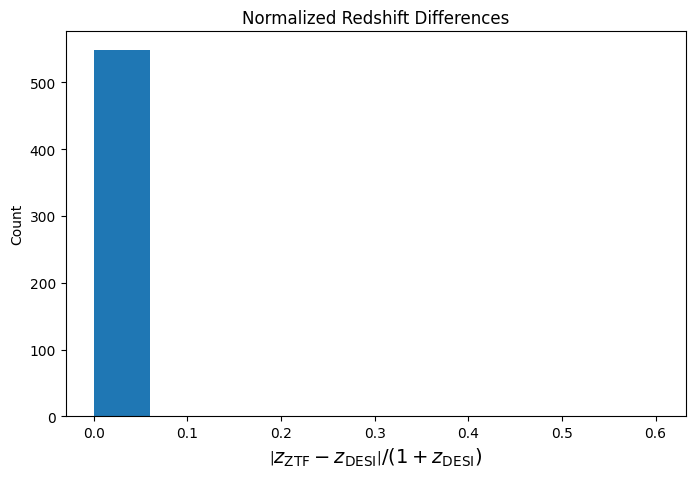

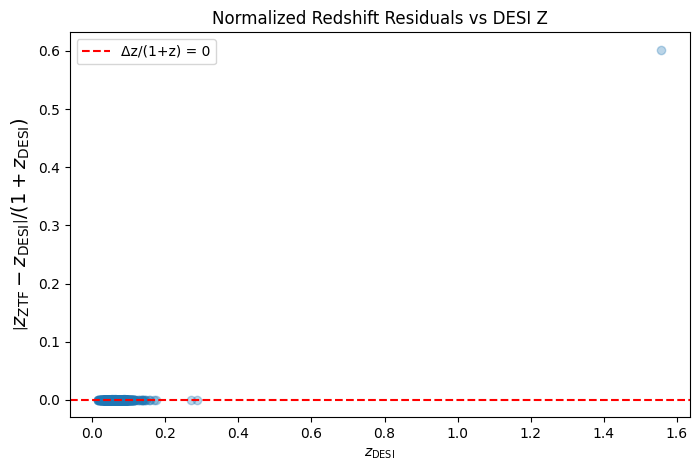

In [12]:
# === Calculate |Δz / (1+z)| using DESI spectroscopic redshift ===
DELTA_Z_NORM = (
    (df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["ZTF_redshift"] - df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["DESI_METADATA_Z"]).abs()
    / (1 + df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["DESI_METADATA_Z"])
)

print(DELTA_Z_NORM.describe())

plt.figure(figsize=(8, 5))
plt.hist(DELTA_Z_NORM)
plt.xlabel(r"$\left|z_{\mathrm{ZTF}} - z_{\mathrm{DESI}}\right| / (1 + z_{\mathrm{DESI}})$", fontsize=14)
plt.ylabel("Count")
plt.title("Normalized Redshift Differences")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts["DESI_METADATA_Z"], DELTA_Z_NORM, alpha=0.3)
plt.axhline(0, color='r', linestyle='--', label='Δz/(1+z) = 0')
plt.xlabel(r"$z_{\mathrm{DESI}}$")
plt.ylabel(r"$\left|z_{\mathrm{ZTF}} - z_{\mathrm{DESI}}\right| / (1 + z_{\mathrm{DESI}})$", fontsize=14)
plt.title("Normalized Redshift Residuals vs DESI Z")
plt.legend()
plt.show()

### Z - filter ###

It looks like some of our matches are actually pretty far away from each other in the redshift direction. We will discard any observations where |Δz| > 0.5. NOTE: this is something that was put in place during our class earlier in the spring w/t Jeff Newman. The reasoning behind the 0.5 cutoff is not well understod. Here is an elementary explanation behind it:


A **Δz ≈ 0.05** is actually *quite large* if we are talking about matching the **same galaxy** between the DES 5YR and DESI datasets.

**Why this is significant:**
- Typical **spectroscopic redshift precision** is on the order of *10⁻⁴ to 10⁻³* (differences of 0.0001–0.001), especially for galaxies with good signal-to-noise (S/N) spectra.
- A Δz = 0.05 corresponds to a velocity difference of roughly:

$$
\Delta v \approx c \times \frac{\Delta z}{1+z} \approx 15,000 \ \text{km/s} \quad (\text{for } z \sim 0.3)
$$

Such a large Δz often indicates:
- A mismatch between objects in the two catalogs (wrong galaxy matched).
- A poor-quality redshift measurement in one of the surveys.
- Different physical objects entirely (e.g., matching to a QSO instead of a galaxy).

Before cut: 550
After cut:  539
Rejected:   11


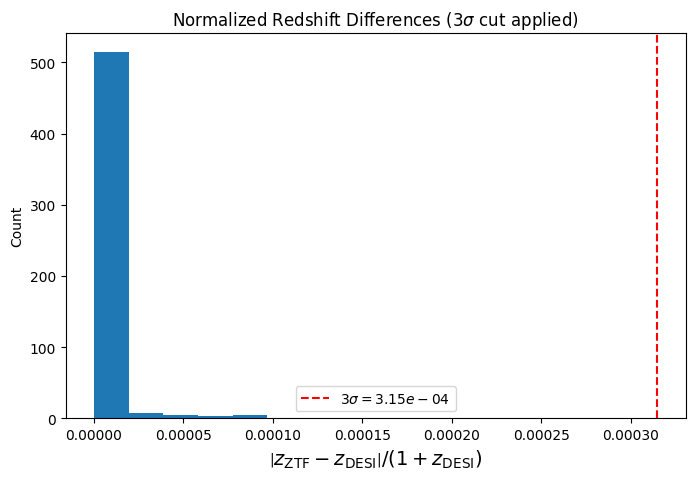

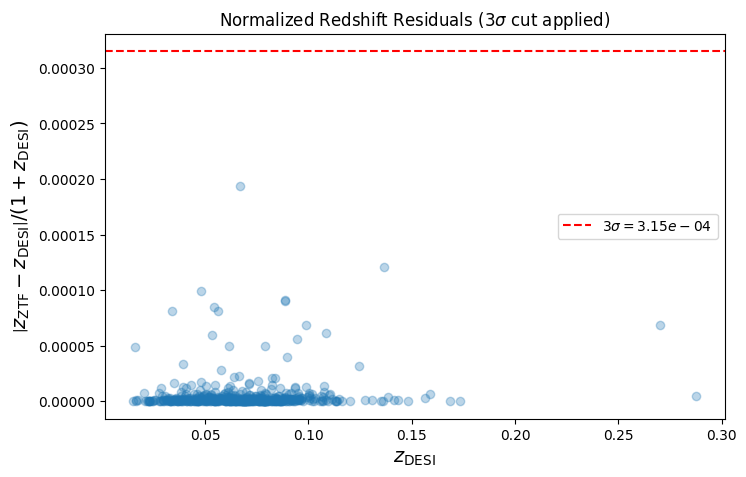

In [15]:
# === Apply 3σ threshold cut ===
THRESHOLD = 3.15e-4
# THRESHOLD = 0.01

mask = DELTA_Z_NORM <= THRESHOLD
n_before = len(DELTA_Z_NORM)
n_after = mask.sum()
print(f"Before cut: {n_before}")
print(f"After cut:  {n_after}")
print(f"Rejected:   {n_before - n_after}")

df_cut = df_merged_wt_hosts_and_lc_and_DESI_metadata_and_lc_cuts[mask].copy()
DELTA_Z_NORM_cut = DELTA_Z_NORM[mask]

# --- Histogram ---
plt.figure(figsize=(8, 5))
plt.hist(DELTA_Z_NORM_cut)
plt.axvline(THRESHOLD, color='r', linestyle='--', label=rf"$3\sigma = {THRESHOLD:.2e}$")
plt.xlabel(r"$\left|z_{\mathrm{ZTF}} - z_{\mathrm{DESI}}\right| / (1 + z_{\mathrm{DESI}})$", fontsize=14)
plt.ylabel("Count")
plt.title(rf"Normalized Redshift Differences ($3\sigma$ cut applied)")
plt.legend()
plt.show()

# --- Scatter plot ---
plt.figure(figsize=(8, 5))
plt.scatter(df_cut["DESI_METADATA_Z"], DELTA_Z_NORM_cut, alpha=0.3)
plt.axhline(THRESHOLD, color='r', linestyle='--', label=rf"$3\sigma = {THRESHOLD:.2e}$")
plt.xlabel(r"$z_{\mathrm{DESI}}$", fontsize=14)
plt.ylabel(r"$\left|z_{\mathrm{ZTF}} - z_{\mathrm{DESI}}\right| / (1 + z_{\mathrm{DESI}})$", fontsize=14)
plt.title(rf"Normalized Redshift Residuals ($3\sigma$ cut applied)")
plt.legend()
plt.show()

# Saving the Final CSV File #

In [18]:
df_cut.to_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts.csv", index=False)
print(df_cut.info())

<class 'pandas.core.frame.DataFrame'>
Index: 539 entries, 0 to 778
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    539 non-null    int64  
 1   ztfname                           539 non-null    object 
 2   ZTF_redshift                      539 non-null    float64
 3   ZTF_redshift_err                  539 non-null    float64
 4   ZTF_source                        539 non-null    object 
 5   ZTF_t0                            539 non-null    float64
 6   ZTF_x0                            539 non-null    float64
 7   ZTF_x1                            539 non-null    float64
 8   ZTF_c                             539 non-null    float64
 9   ZTF_t0_err                        539 non-null    float64
 10  ZTF_x0_err                        539 non-null    float64
 11  ZTF_x1_err                        539 non-null    float64
 12  ZTF_c_err    